In [1]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables numpy seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 21.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 87.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 221.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 207.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 128.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 226.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 149.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 188.4 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from mts_study import *

# Setup

In [3]:
# plot setup
plt.rcParams['figure.figsize'] = [14,8]

color_map = {
    "libfabric": "blue",
    "native": "orange",
    "ucx": "green",
    "libfabric-fix": "red",
}

sns.set_theme(style="whitegrid")

data_dir = "../data/mts-study"

# Transfers

## Device to Device Inter-Host

In [4]:
config = {"libraries":[Library.libfabric, Library.native], "tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}
data, perf, _ = load_data(f"{data_dir}/d2d-interhost", timers_loader, **config)

### Comparison spin vs wait with native and 3840x2160

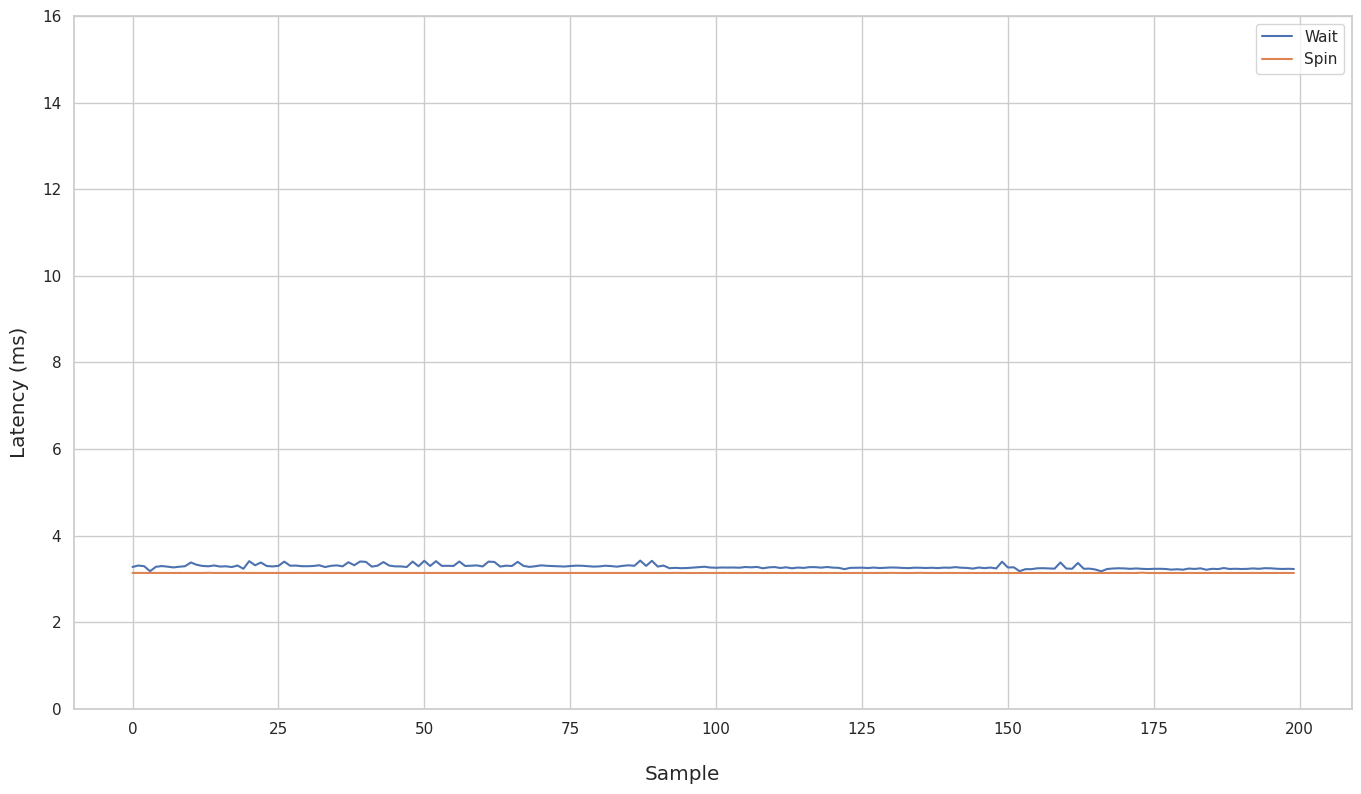

In [5]:
ymin, ymax = 0, 16
fig, axs = plt.subplots()
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for comp in config["completions"]:
    axs.set_ylim(ymin, ymax)
    axs.plot(data[TestConfiguration(Library.native, Format._2160, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/2/1e6, label=f"{comp.value}")
    axs.legend()

### Comparison libfabric vs native for Device to Device Inter-Host transfers

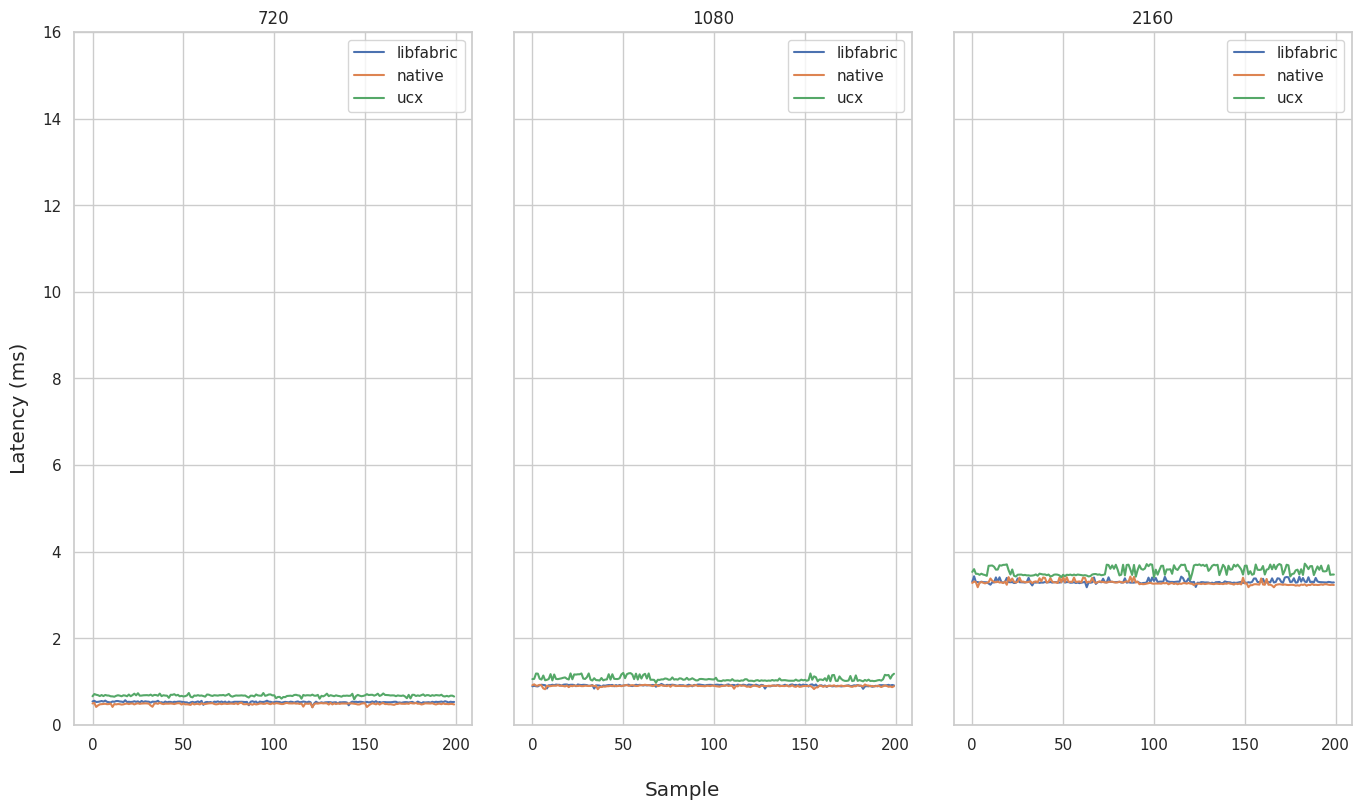

In [6]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=1,ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}")
    axs[i].set_ylim(ymin, ymax)
    for library in [Library.libfabric,  Library.native]:
        axs[i].plot(data[TestConfiguration(library, format, Completion.wait, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/2/1e6, label=f"{library.value}")
    axs[i].plot(data[TestConfiguration(Library.ucx, format, Completion.wait, Test.ucx, Movement.d2d, Transport.none, TransferMode.reflect)]/2/1e6, label=f"ucx")
    axs[i].legend()

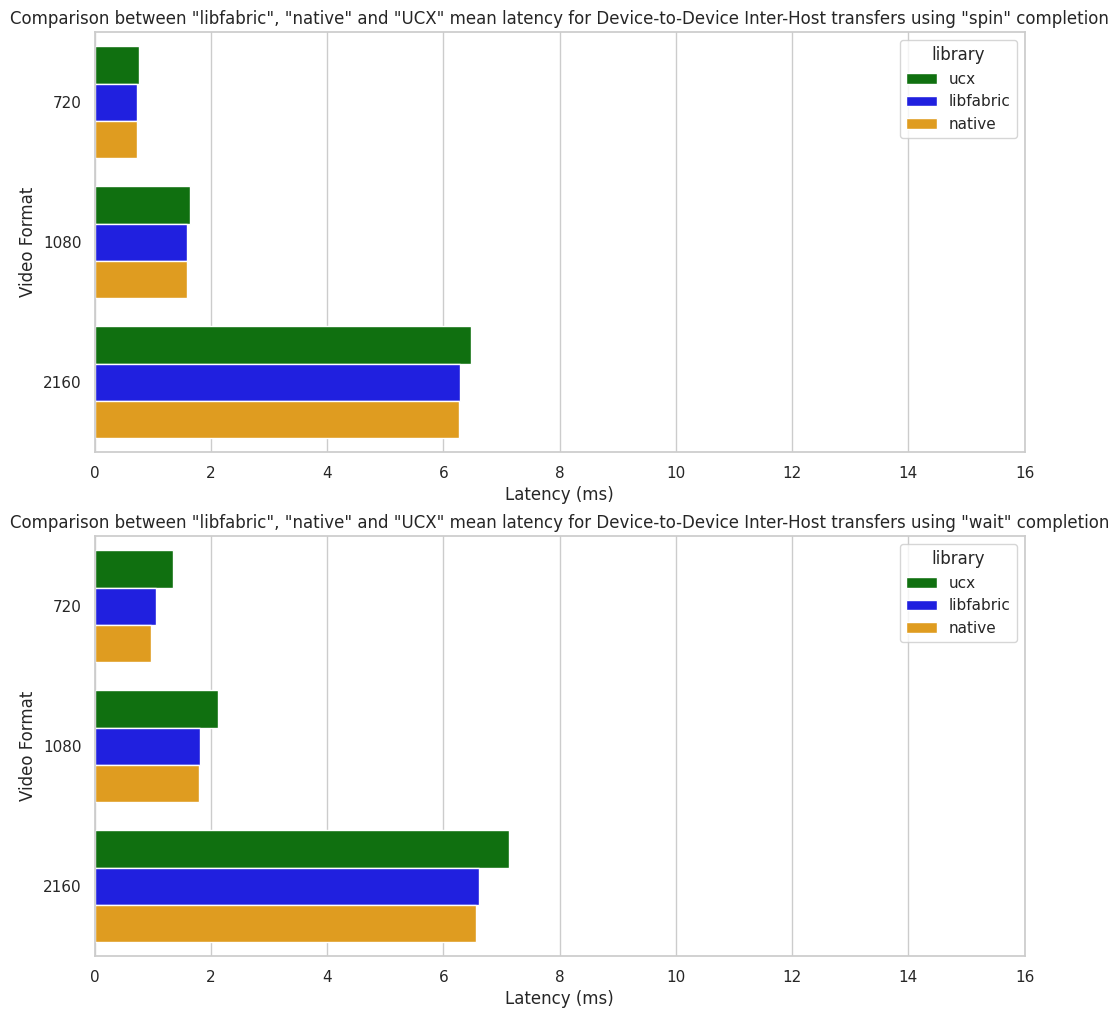

In [7]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

comps=[Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "native" and "UCX" mean latency for Device-to-Device Inter-Host transfers using "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [8]:
data_columns = ["format", "library", "completion"]
data_df = make_table(data, perf,columns=data_columns).sort(["format"]).filter(pl.col("completion") == "Wait")
table= GT(data_df)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison with \"wait\" completion",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["completion"])
)

GT(_tbl_data=shape: (9, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ libfabric ┆ Wait       ┆ 1.0491   ┆ 1.134   ┆ 0.0339  ┆ 0.0098    │
│ 720    ┆ native    ┆ Wait       ┆ 0.9663   ┆ 1.02    ┆ 0.0334  ┆ 0.0109    │
│ 720    ┆ ucx       ┆ Wait       ┆ 1.3495   ┆ 1.4685  ┆ 0.0444  ┆ 0.01      │
│ 1080   ┆ libfabric ┆ Wait       ┆ 1.8195   ┆ 1.888   ┆ 0.0336  ┆ 0.01      │
│ 1080   ┆ native    ┆ Wait       ┆ 1.7925   ┆ 1.8695  ┆ 0.0327  ┆ 0.0127    │
│ 1080   ┆ ucx       ┆ Wait       ┆ 2.1257   ┆ 2.3951  ┆ 0.1075  ┆ 0.0143    │
│ 2160   ┆ libfabric ┆ Wait       ┆ 6.6121   ┆ 6.8603  ┆ 0.085   ┆ 0.01      │
│ 2160   ┆ native    ┆ Wait       ┆ 6.5588   ┆ 6.846   ┆ 0.0973  ┆ 0.0114    │
│ 2160   ┆ ucx       ┆ Wait       ┆ 7.124    ┆ 7.4432  ┆ 0.1998  ┆ 0.0105    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x70f7f413abd0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.hidden: 4>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x70f7f5d10ad0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison with "wait" completion', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x70f7f5d67010>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size

## Device to Host 2 Host to Device Inter-host

In [9]:
config = {"libraries":[Library.libfabric, Library.native],"tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d, Movement.dh2hd], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait]}

# load data
data, perf, pcie = load_data(f"{data_dir}/dh2hd-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device-to-Host-to-Host-to-Device transfers

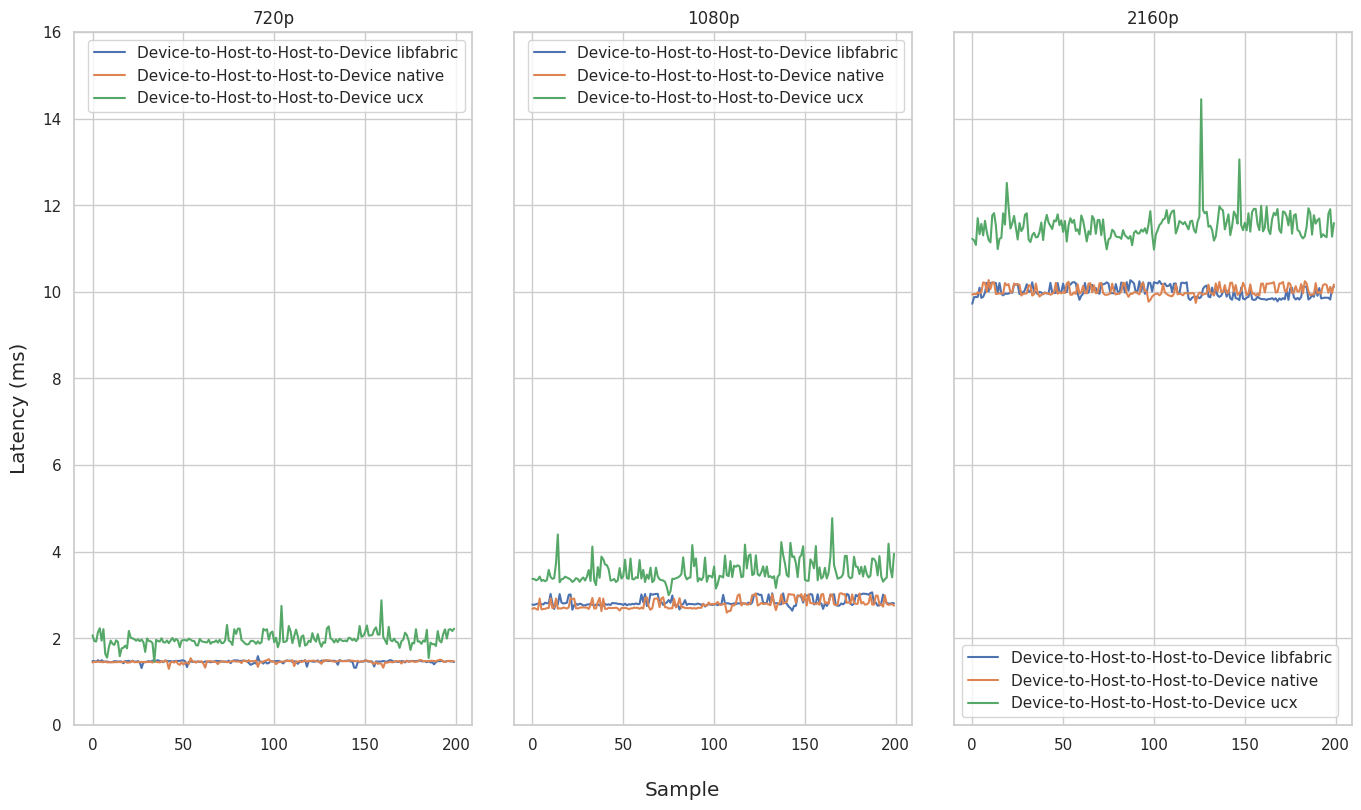

In [10]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(ymin, ymax)
    for library in config["libraries"]:
        axs[i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.to_study_name()} {library.value}")
    axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.dh2hd, Transport.none, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.to_study_name()} ucx")
    axs[i].legend()

KeyError: TestConfiguration(library=<Library.libfabric: 'libfabric'>, format=<Format._720: '720'>, completion=<Completion.spin: 'Spin'>, test=<Test.mxl_fabrics: 'MXLFabrics'>, movement=<Movement.dh2hd: 'Cuda2Host2Host2Cuda'>, transport=<Transport.verbs: 'Verbs'>, tx_mode=<TransferMode.reflect: 'Reflect'>)

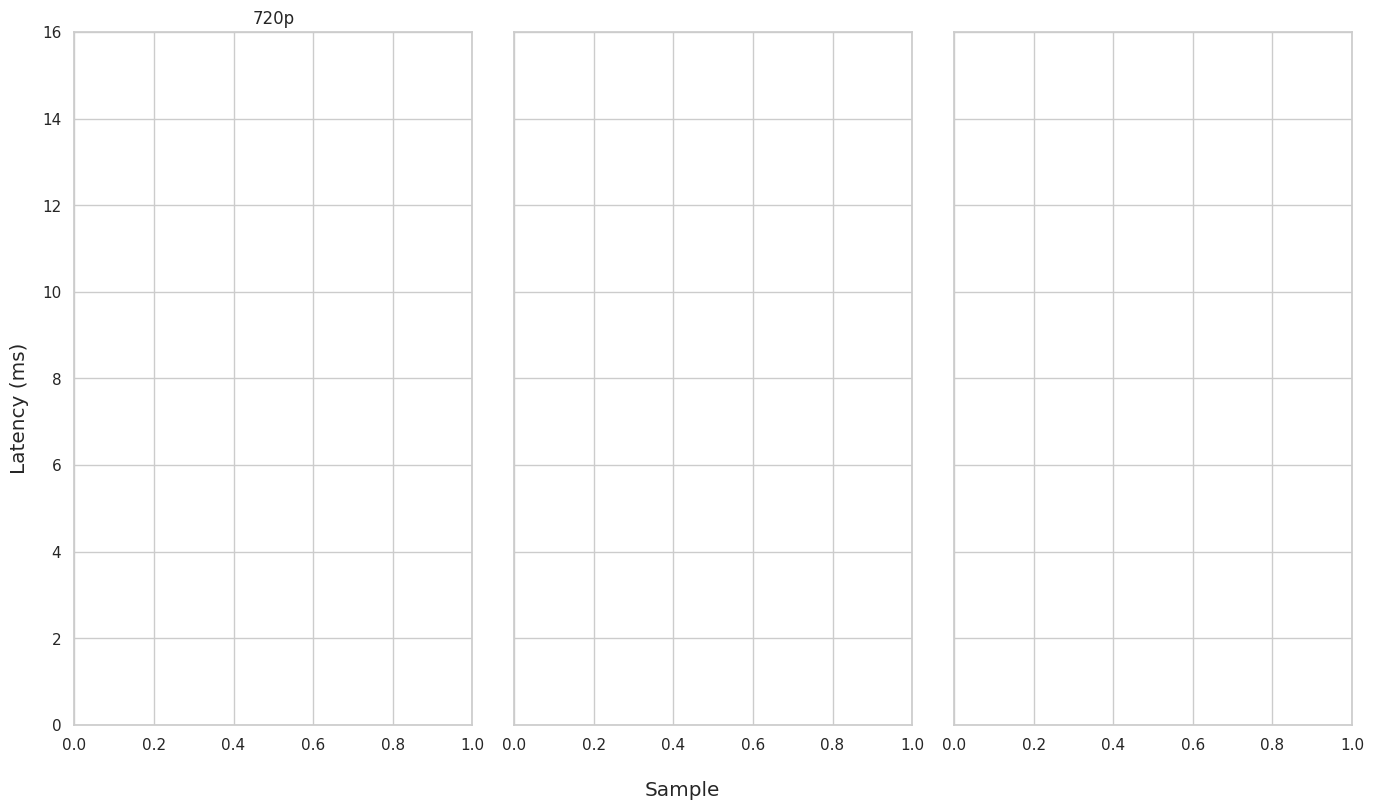

In [11]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=1,ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(ymin, ymax)
    for library in config["libraries"]:
        axs[i].plot(data[TestConfiguration(library, format, Completion.spin, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.to_study_name()} {library.value}")
    axs[i].plot(data[TestConfiguration(Library.ucx, format, Completion.spin, Test.ucx, Movement.dh2hd, Transport.none, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.to_study_name()} ucx")
    axs[i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using libfabric

In [ ]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=1,ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}")
    axs[i].set_ylim(ymin, ymax)
    for movement in config["movements"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, Completion.wait, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} libfabric")
        axs[i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using native

In [ ]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=1,ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}")
    axs[i].set_ylim(ymin, ymax)
    for movement in config["movements"]:
        axs[i].plot(data[TestConfiguration(Library.native, format, Completion.wait, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} native")
        axs[i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using UCX

In [ ]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=1,ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}")
    axs[i].set_ylim(ymin, ymax)
    for movement in config["movements"]:
        axs[i].plot(data[TestConfiguration(Library.ucx, format, Completion.wait, Test.ucx, movement, Transport.none, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} ucx")
        axs[i].legend()
        

In [ ]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col.movement.cast(pl.Categorical)
)
data_df = data_df.filter((pl.col.completion == Completion.none) | (pl.col.completion == Completion.wait), pl.col.library == Library.libfabric)
data_df = data_df.with_columns(
    pl.col.movement.map_elements(lambda m:  Movement(m).to_study_name(), return_dtype=str)
)

fig, ax = plt.subplots(figsize=(16, 8))
# ax.set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "libfabric" and "{comp.name}" completion')
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Video Format")
ax.set_xlim(0,16)
sns.barplot(data=data_df, x='lat_mean', y="format", hue='movement', orient='h', ax=ax);

In [ ]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf, pcie,columns=data_columns).filter(pl.col.completion == Completion.wait).sort(["format"])
data_df = data_df.with_columns(
    pl.col.movement.map_elements(lambda m:  Movement(m).to_study_name(), return_dtype=str)
)
data_df_720 = data_df.filter(pl.col("format") == "720")
data_df_1080 = data_df.filter(pl.col("format") == "1080")
data_df_2160 = data_df.filter(pl.col("format") == "2160")

In [ ]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 1280x720 frames with \"wait\" completion",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["completion"])
)

In [ ]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 1920x1080 frames with \"wait\" completion",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["completion"])
)

In [ ]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 3840x2160 frames with \"wait\" completion",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["completion"])
)

### Display latency increase in % when doing DH2HD instead of D2D

In [ ]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf, pcie,columns=data_columns).filter(pl.col.completion == Completion.wait).sort(["format"])
mean_lat_per_format_and_movement = (
    data_df
    .group_by(["format", "movement"])
    .agg([
        pl.col("lat_mean").mean().alias("mean_avg"),
    ])
)

df_ratio = pl.DataFrame()
for format in Format:
    d2d =  mean_lat_per_format_and_movement.filter(pl.col("format") == format.value, pl.col("movement") == Movement.d2d.value).select(pl.col("mean_avg"))
    dh2hd =  mean_lat_per_format_and_movement.filter(pl.col("format") == format.value, pl.col("movement") == Movement.dh2hd.value).select(pl.col("mean_avg"))
    ratio = round((dh2hd.item() / d2d.item() - 1) * 100, 4)
    df_ratio = df_ratio.vstack(pl.DataFrame({"format": format.value, "lat_mean": ratio}))
    
table = GT(df_ratio)

table
(
    table
    .cols_label(lat_mean="latency diff (%)")
)

In [ ]:

new_df = pl.DataFrame()
for format in Format:
    for library in [Library.libfabric, Library.native, Library.ucx]:
        d2d = data_df.filter(pl.col("format") == format.value, pl.col("library") == library, pl.col("completion") == "Wait", pl.col("movement") == Movement.d2d.value).select(pl.col("lat_mean"))
        dh2hd = data_df.filter(pl.col("format") == format.value, pl.col("library") == library, pl.col("completion") == "Wait", pl.col("movement") == Movement.dh2hd.value).select(pl.col("lat_mean"))
        ratio = round((dh2hd.item() / d2d.item() - 1) * 100, 4)
        new_df = new_df.vstack(pl.DataFrame({"format": format.value, "framework": library.value, "completion": comp.name, "lat_mean": ratio}))
        
table = GT(new_df)

table
(
    table
    .cols_label(lat_mean="latency diff (%)")
    .cols_hide(columns="completion")
)

## Host to Device Intra-Host

In [12]:
config = {"libraries": [Library.libfabric, Library.libfabric_fix], "movements": [Movement.h2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/h2d-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Host-to-Device transfers

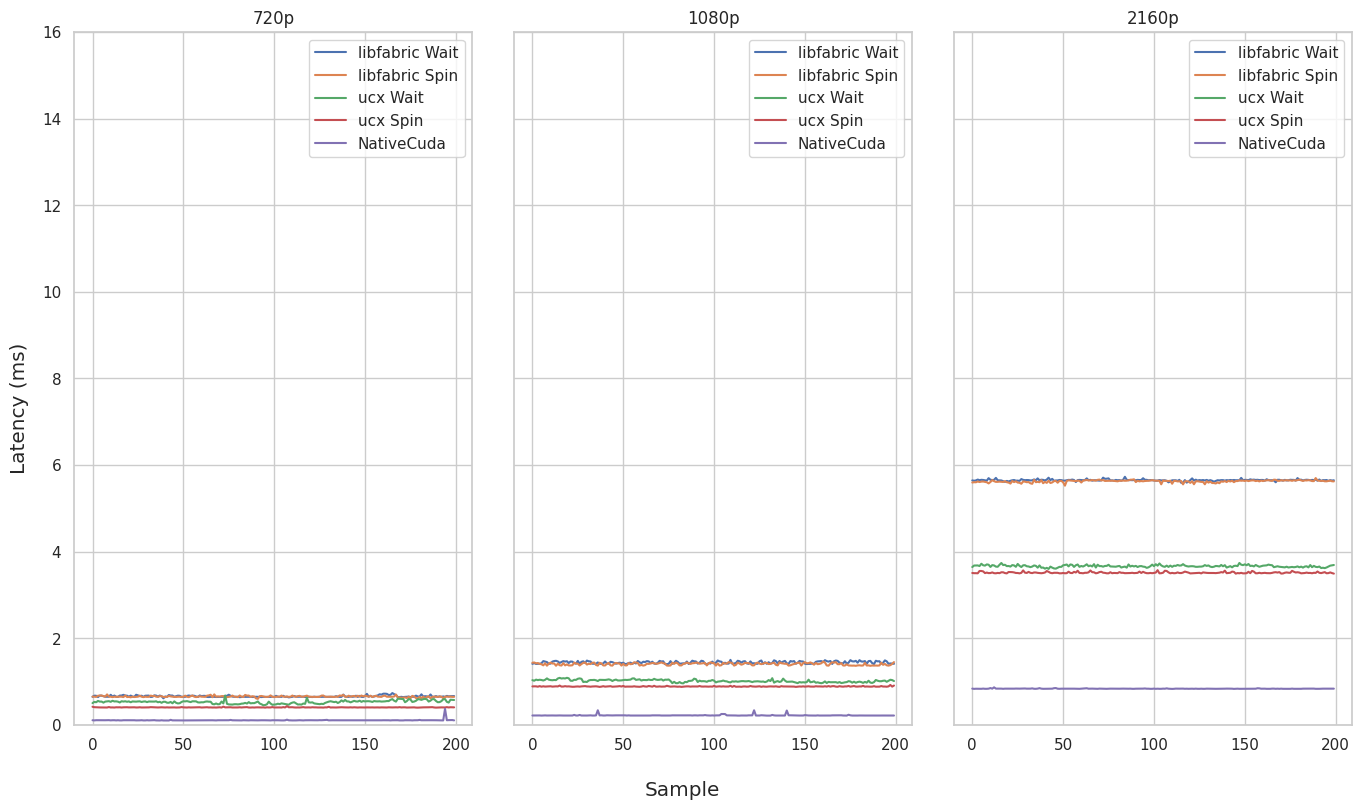

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
        
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.h2d, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")

    # for comp in config["completions"]:
    #     axs[i].plot(data[TestConfiguration(Library.libfabric_fix, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric-fix {comp.value}")
        
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

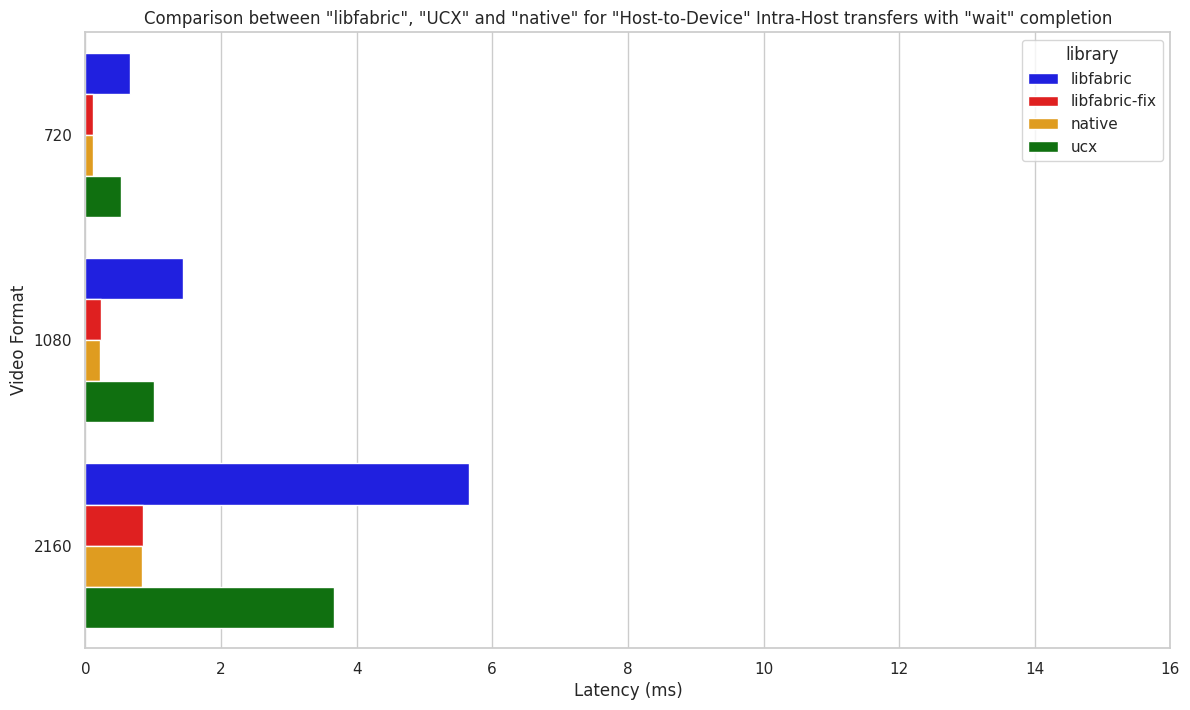

In [14]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
data_df = data_df.filter((pl.col("completion") == Completion.none.value) |  (pl.col("completion") == Completion.wait.value))
comps = [Completion.spin, Completion.wait]
fig, ax = plt.subplots()
ax.set_title(f'Comparison between "libfabric", "UCX" and "native" for "Host-to-Device" Intra-Host transfers with "wait" completion')
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Video Format")
ax.set_xlim(0,16)
sns.barplot(data=data_df, x='lat_mean', y="format", hue='library', orient='h', ax=ax, palette=color_map);

In [15]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns).filter((pl.col("completion") == Completion.none.value) | (pl.col("completion") == Completion.wait.value)).sort(["format"])
table = GT(data_df)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison with \"wait\" completion",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["completion", "movement"])
)

GT(_tbl_data=shape: (12, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 0.658    ┆ 0.733   ┆ 0.0188  ┆ 0.0831    │
│ 720    ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.1119   ┆ 0.1626  ┆ 0.0087  ┆ 0.0128    │
│ 720    ┆ native        ┆            ┆ Host2Cuda ┆ 0.1054   ┆ 0.369   ┆ 0.0189  ┆ 0.0209    │
│ 720    ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 0.5272   ┆ 0.6764  ┆ 0.0361  ┆ 0.0127    │
│ 1080   ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 1.441    ┆ 1.4994  ┆ 0.0275  ┆ 0.1772    │
│ …      ┆ …             ┆ …          ┆ …         ┆ …        ┆ …       ┆ …       ┆ …         │
│ 1080   ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 1.0134   ┆ 1.0853  ┆ 0.0296  ┆ 0.0108    │
│ 2160   ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 5.6504   ┆ 5.7275  ┆ 0.0186  ┆ 0.6798    │
│ 2160   ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.8542   ┆ 0.902   ┆ 0.0062  ┆ 0.0555    │
│ 2160   ┆ native        ┆            ┆ Host2Cuda ┆ 0.8342   ┆ 0.8653  ┆ 0.0038  ┆ 0.1039    │
│ 2160   ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 3.6647   ┆ 3.7378  ┆ 0.0246  ┆ 0.0106    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x70f7c9df7250>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.hidden: 4>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x70f7c9cf05d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison with "wait" completion', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x70f7c9c17cd0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category

## Device to Host Intra-Host

In [ ]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2h], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/d2h-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda vs UCX for Device-to-Host transfers

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2h, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

In [ ]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"]).sort(pl.col("library"))
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)
data_df = data_df.filter((pl.col("completion") == Completion.none.value) | (pl.col("completion") == Completion.wait.value))

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title(f'Comparison between "libfabric", "UCX" and "native" for "Device-to-Host" Intra-Host transfers with "wait" completion')
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Video Format")
ax.set_xlim(0,16)
sns.barplot(data=data_df, x='lat_mean', y="format", hue='library', orient='h', ax=ax, palette=color_map);

In [ ]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns).filter((pl.col("completion") == Completion.wait.value) | (pl.col("completion") == Completion.none.value)).sort(["format"])
table = GT(data_df)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison with \"wait\" completion",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["completion", "movement"])
)

## Device to Device Intra-host Inter-GPU

In [16]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/d2d-intrahost", diff_loader, **config)

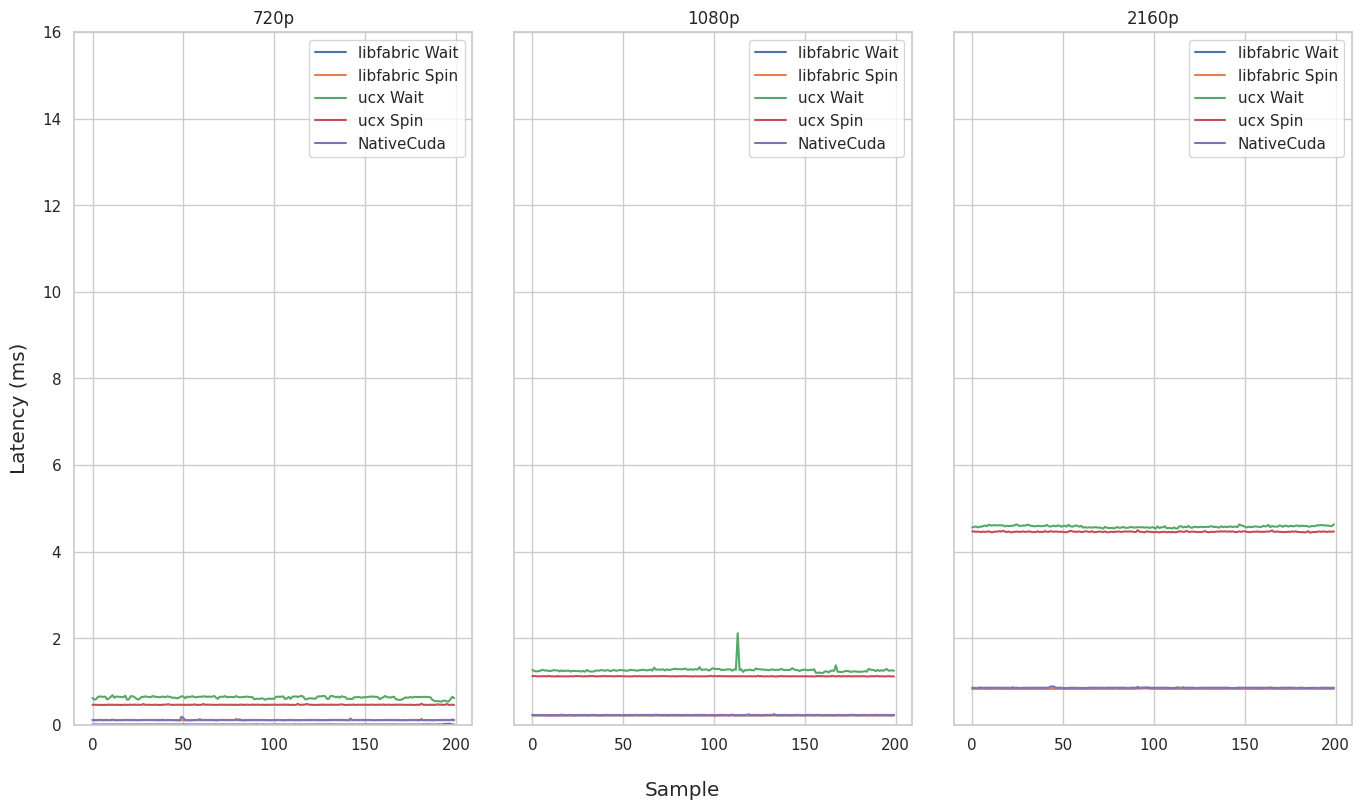

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2d, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

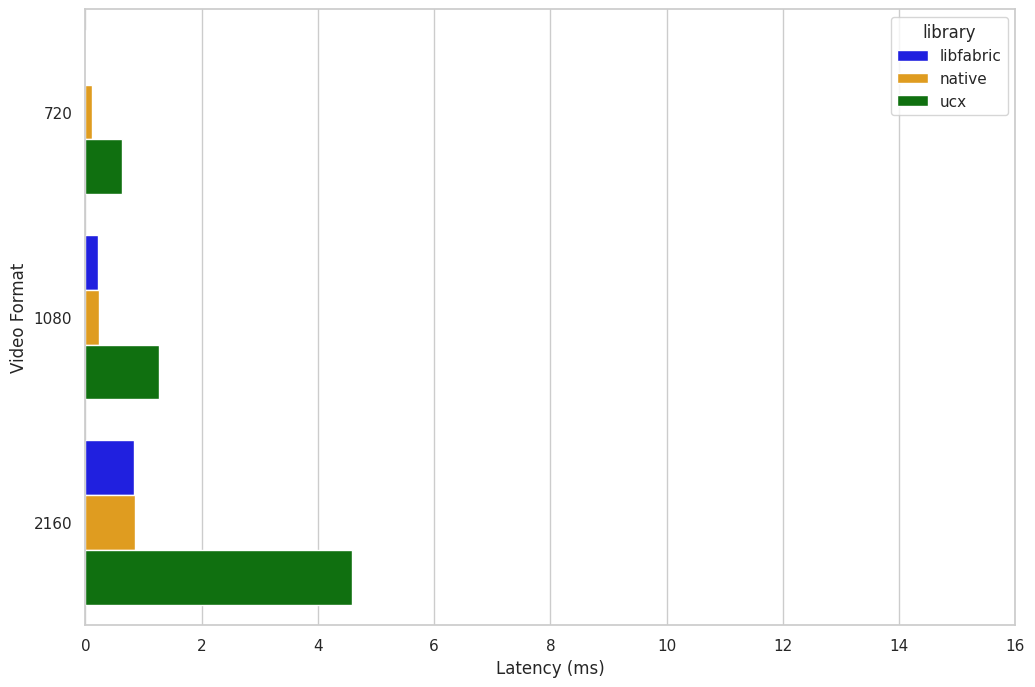

In [18]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"]).sort(pl.col("library"))
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

fig, ax = plt.subplots(figsize=(12, 8))
# ax.set_title(f'Comparison between "libfabric", "UCX" and "native" for "Device-to-Device" Intra-Host transfers with "wait" completion')
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Video Format")
ax.set_xlim(0,16)
sns.barplot(data=data_df.filter((pl.col("completion") == Completion.none.value) | (pl.col("completion") == Completion.wait.value)), x='lat_mean', y="format", hue='library', orient='h', ax=ax, palette=color_map);

In [19]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns).filter((pl.col("completion") == Completion.wait.value) | (pl.col("completion") == Completion.none.value)).sort("format")
table = GT(data_df)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["completion", "movement"])
)

GT(_tbl_data=shape: (9, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ libfabric ┆ Wait       ┆ Cuda2Cuda ┆ 0.0075   ┆ 0.0246  ┆ 0.0022  ┆ 0.0091    │
│ 720    ┆ native    ┆            ┆ Cuda2Cuda ┆ 0.1116   ┆ 0.1878  ┆ 0.0076  ┆ 0.0186    │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Cuda ┆ 0.6293   ┆ 0.6842  ┆ 0.0296  ┆ 0.0152    │
│ 1080   ┆ libfabric ┆ Wait       ┆ Cuda2Cuda ┆ 0.2189   ┆ 0.2457  ┆ 0.0029  ┆ 0.031     │
│ 1080   ┆ native    ┆            ┆ Cuda2Cuda ┆ 0.2259   ┆ 0.2439  ┆ 0.0032  ┆ 0.0321    │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda ┆ 1.2639   ┆ 2.1158  ┆ 0.0649  ┆ 0.0112    │
│ 2160   ┆ libfabric ┆ Wait       ┆ Cuda2Cuda ┆ 0.8378   ┆ 0.8761  ┆ 0.0042  ┆ 0.1046    │
│ 2160   ┆ native    ┆            ┆ Cuda2Cuda ┆ 0.856    ┆ 0.8852  ┆ 0.0046  ┆ 0.1072    │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda ┆ 4.5786   ┆ 4.6307  ┆ 0.0215  ┆ 0.0109    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x70f7c9c17150>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.default: 1>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.hidden: 4>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x70f7ef571d90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1280x720 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x70f7f40081d0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(s